In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("da_sales_transactions.csv")

df.head()

,Transaction_ID,Date,Customer_ID,Product_ID,Category,Units,Unit_Price,Discount_Pct,Channel,City,Return_Flag
0,T1,2025-01-24,C2,P2,Sports,5,539,15,Marketplace,Pune,1
1,T2,2025-12-15,C3,P3,Grocery,1,4228,5,Marketplace,Delhi,0
2,T3,2025-10-11,C4,P4,Books,2,2061,15,Offline,Chennai,0
3,T4,2025-04-24,C5,P5,Electronics,3,2164,0,Website,Chennai,0
4,T5,2025-06-25,C6,P6,Apparel,1,2341,0,Website,Kolkata,0


# Basic Probability Using a Contingency Table

In [2]:
table = pd.crosstab(df["Channel"], df["Return_Flag"])

print(table)

Return_Flag    0   1
Channel             
App          223  27
Marketplace  238  17
Offline      221  25
Website      221  28


In [ ]:
#Calculate P(A)
P_A = (df["Channel"] == "Online").mean()

print("P(A):", P_A)

#Calculate P(B)
P_B = (df["Return_Flag"] == 1).mean()

print("P(B):", P_B)

#Calculate P(A ∩ B)
P_A_and_B = (
    (df["Channel"] == "Online") &
    (df["Return_Flag"] == 1)
).mean()

print("P(A ∩ B):", P_A_and_B)

#Calculate P(A | B)
P_A_given_B = P_A_and_B / P_B if P_B != 0 else 0

print("P(A | B):", P_A_given_B)

P(A): 0.0
P(B): 0.097
P(A ∩ B): 0.0
P(A | B): 0.0


# Normal Distribution

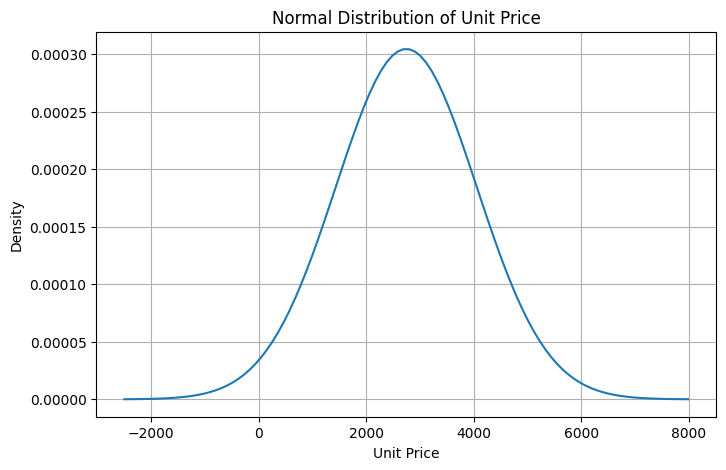

In [4]:
from scipy.stats import norm

mean = df["Unit_Price"].mean()
std = df["Unit_Price"].std()

x = np.linspace(
    mean - 4*std,
    mean + 4*std,
    100
)

y = norm.pdf(x, mean, std)

plt.figure(figsize=(8,5))
plt.plot(x, y)

plt.title("Normal Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Density")
plt.grid()
plt.show()

68-95-99.7 Rule

The empirical rule says:

68% → within ±1 standard deviation
95% → within ±2 standard deviations
99.7% → within ±3 standard deviations

In [5]:
print("68% range:",
      mean - std,
      "to",
      mean + std)

print("95% range:",
      mean - 2*std,
      "to",
      mean + 2*std)

print("99.7% range:",
      mean - 3*std,
      "to",
      mean + 3*std)

68% range: 1436.14872866419 to 4055.5192713358097
95% range: 126.46345732838017 to 5365.2045426716195
99.7% range: -1183.2218140074297 to 6674.889814007429


# Binomial Distribution Simulation

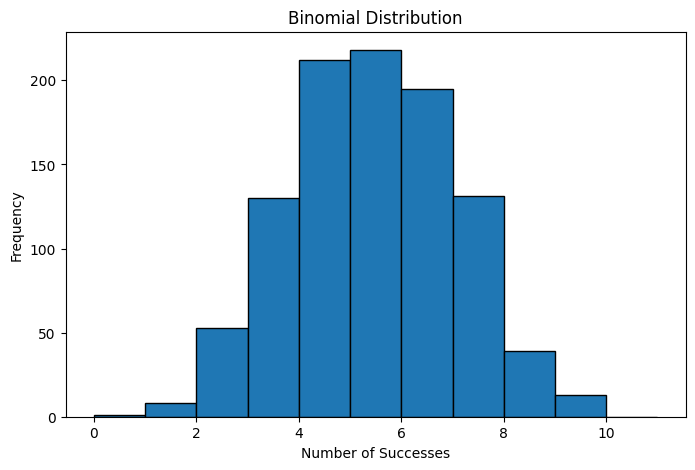

In [6]:
n = 10
p = 0.5

results = np.random.binomial(n, p, 1000)

plt.figure(figsize=(8,5))
plt.hist(results, bins=range(12), edgecolor="black")

plt.title("Binomial Distribution")
plt.xlabel("Number of Successes")
plt.ylabel("Frequency")
plt.show()

# Central Limit Theorem Simulation
Even if the original population is not normally distributed, the distribution of sample means becomes approximately normal as the sample size increases.

In [7]:
population = df["Unit_Price"].values

sample_means = []

for i in range(1000):
    sample = np.random.choice(population, 30)
    sample_means.append(sample.mean())

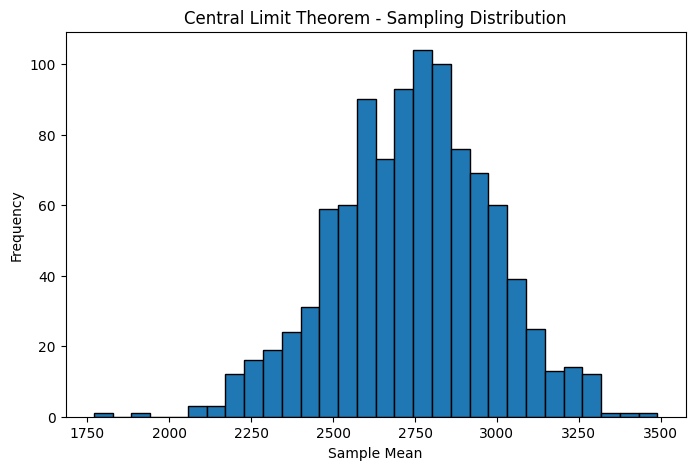

In [8]:
plt.figure(figsize=(8,5))

plt.hist(sample_means, bins=30, edgecolor="black")

plt.title("Central Limit Theorem - Sampling Distribution")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show() 

In [9]:
print("Population Mean:", population.mean())
print("Mean of Sample Means:", np.mean(sample_means))

Population Mean: 2745.834
Mean of Sample Means: 2743.0777000000003
